In [9]:
# ============================================================
# FASE 8 — BASELINE EXPERIMENT
#
# CELL 1
#
# Menghubungkan Google Drive sebagai penyimpanan eksperimen
# ============================================================


from google.colab import drive


drive.mount(
    "/content/drive"
)


print("=" * 70)
print("GOOGLE DRIVE BERHASIL TERHUBUNG")
print("=" * 70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GOOGLE DRIVE BERHASIL TERHUBUNG


In [10]:
# ============================================================
# CELL 2
#
# Mengambil source code penelitian dari GitHub
#
# Repository hanya digunakan sebagai source code.
# Output eksperimen tetap disimpan di Google Drive.
# ============================================================


import os
import subprocess


REPO_PATH = "/content/label-noise-thesis"


GITHUB_URL = (
    "https://github.com/"
    "luthfiaw13/"
    "label-noise-thesis.git"
)



if not os.path.exists(REPO_PATH):

    print(
        "Repository belum tersedia."
    )

    subprocess.run(
        [
            "git",
            "clone",
            GITHUB_URL,
            REPO_PATH
        ],
        check=True
    )


else:

    print(
        "Repository sudah tersedia."
    )



print("=" * 70)
print("REPOSITORY SIAP DIGUNAKAN")
print("=" * 70)

Repository sudah tersedia.
REPOSITORY SIAP DIGUNAKAN


In [ ]:
# ============================================================
# CELL 3
#
# Import library eksperimen
# ============================================================


import sys
import json
import random
import time


from pathlib import Path


import numpy as np
import pandas as pd


import torch
import torch.nn as nn


from torch.utils.data import DataLoader, random_split


import matplotlib.pyplot as plt


from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score
)



print("=" * 70)
print("LIBRARY DASAR BERHASIL DIMUAT")
print("=" * 70)

LIBRARY DASAR BERHASIL DIMUAT


In [ ]:
# ============================================================
# CELL 4
#
# Menghubungkan source code repository
# ============================================================


if REPO_PATH not in sys.path:

    sys.path.append(
        REPO_PATH
    )


print("=" * 70)
print("PYTHON PATH REPOSITORY AKTIF")
print("=" * 70)

PYTHON PATH REPOSITORY AKTIF


In [ ]:
# ============================================================
# CELL 5
#
# Import source code penelitian
# ============================================================


from src.models.resnet import (
    bangun_resnet_cifar
)


from src.training.engine import (
    buat_scheduler_warmup_cosine,
    latih_hingga_step
)


from src.training.checkpoint import (
    simpan_checkpoint
)


from src.data.cifar import (
    CIFAR10Berindeks,
    buat_transformasi_cifar10
)


from torchvision.datasets import CIFAR10


print("=" * 70)
print("SOURCE CODE PENELITIAN BERHASIL DIMUAT")
print("=" * 70)


print("✅ Model")
print("✅ Training Engine")
print("✅ Checkpoint")
print("✅ Dataset CIFAR Berindeks")

SOURCE CODE PENELITIAN BERHASIL DIMUAT
✅ Model
✅ Training Engine
✅ Checkpoint
✅ Dataset CIFAR Berindeks


In [ ]:
# ============================================================
# CELL 6
#
# Membaca Experimental Protocol Freeze
#
# Struktur JSON:
#
# dataset
# └── dataset
#
# model
# training
# evaluation
#
# ============================================================


import json



PROTOCOL_PATH = (

    "/content/drive/MyDrive/"
    "skripsi_label_noise/"
    "configs_snapshot/"
    "experimental_protocol_freeze.json"

)



with open(
    PROTOCOL_PATH,
    "r"
) as file:

    protocol = json.load(file)



# Shortcut konfigurasi
dataset_config = protocol["dataset"]["dataset"]

model_config = protocol["model"]

training_config = protocol["training"]

evaluation_config = protocol["evaluation"]



print("=" * 70)

print(
    "PROTOCOL FREEZE BERHASIL DIMUAT"
)

print("=" * 70)



print(
    "Dataset:",
    dataset_config["name"]
)


print(
    "Train samples:",
    dataset_config["train_samples"]
)


print(
    "Test samples:",
    dataset_config["test_samples"]
)


print(
    "Model:",
    model_config["models"]
)


print(
    "Batch size:",
    training_config["batch_size"]
)


print(
    "Seed:",
    training_config["seed"]
)

PROTOCOL FREEZE BERHASIL DIMUAT
Dataset: CIFAR-10
Train samples: 50000
Test samples: 10000
Model: ['ResNet18', 'ResNet34', 'ResNet50']
Batch size: 256
Seed: 42


In [ ]:
# ============================================================
# CELL 7
#
# Validasi GPU
# ============================================================


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)



print("="*70)
print("VALIDASI DEVICE")
print("="*70)



print(
    "Device:",
    DEVICE
)



if DEVICE.type == "cuda":

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


    print(
        "CUDA:",
        torch.version.cuda
    )


else:

    print(
        "WARNING: GPU tidak aktif"
    )

VALIDASI DEVICE
Device: cuda
GPU: Tesla T4
CUDA: 12.8


In [ ]:
# ============================================================
# CELL 8
#
# Reproducibility
# ============================================================


SEED = training_config["seed"]



def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)



set_seed(SEED)



print("="*70)
print("SEED BERHASIL DITERAPKAN")
print("="*70)


print(
    "Seed:",
    SEED
)

SEED BERHASIL DITERAPKAN
Seed: 42


In [ ]:
# ============================================================
# CELL 9
#
# Membuat direktori output eksperimen
# ============================================================


BASE_OUTPUT = Path(

    "/content/drive/MyDrive/"
    "skripsi_label_noise/"
    "outputs/"
    "phase_8_baseline"

)



CHECKPOINT_DIR = BASE_OUTPUT / "checkpoints"

METRIC_DIR = BASE_OUTPUT / "metrics"

FIGURE_DIR = BASE_OUTPUT / "figures"

PRED_DIR = BASE_OUTPUT / "predictions"

META_DIR = BASE_OUTPUT / "run_metadata"



for folder in [

    CHECKPOINT_DIR,
    METRIC_DIR,
    FIGURE_DIR,
    PRED_DIR,
    META_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )



print("=" * 70)
print("DIREKTORI OUTPUT SIAP")
print("=" * 70)

DIREKTORI OUTPUT SIAP


In [ ]:
# ============================================================
# CELL 10
#
# Membuat transformasi CIFAR-10
# Mengikuti implementasi repository
# ============================================================



train_transform = buat_transformasi_cifar10(
    mode="train"
)



eval_transform = buat_transformasi_cifar10(
    mode="eval"
)



print("=" * 70)
print("TRANSFORMASI DATASET SIAP")
print("=" * 70)

TRANSFORMASI DATASET SIAP


In [ ]:
# ============================================================
# CELL 11
#
# Dataset CIFAR-10 berindeks
# ============================================================


from torchvision.datasets import CIFAR10



dataset_train_asli = CIFAR10(

    root="/content/data",

    train=True,

    download=True

)



labels_train = np.asarray(

    dataset_train_asli.targets,

    dtype=np.int64

)



index_train = np.arange(

    len(labels_train)

)



train_dataset = CIFAR10Berindeks(

    root="/content/data",

    indeks=index_train,

    transform=train_transform,

    download=True

)



print("="*70)

print(
    "TRAIN DATASET SIAP"
)

print("="*70)


contoh = train_dataset[0]


print(
    "Jumlah output:",
    len(contoh)
)


print(
    "Image:",
    contoh[0].shape
)


print(
    "Label:",
    contoh[1]
)


print(
    "Index:",
    contoh[2]
)

TRAIN DATASET SIAP
Jumlah output: 3
Image: torch.Size([3, 32, 32])
Label: 6
Index: 0


In [ ]:
# ============================================================
# CELL 12
#
# Membagi training dan validation
#
# Test tidak digunakan pada tahap ini
# ============================================================



train_size = int(

    0.9 *

    len(train_dataset)

)



validation_size = (

    len(train_dataset)

    -

    train_size

)



train_subset, val_subset = random_split(

    train_dataset,

    [

        train_size,

        validation_size

    ],

    generator=torch.Generator()
    .manual_seed(SEED)

)



print("=" * 70)
print("DATA SPLIT BASELINE")
print("=" * 70)


print(
    "Training:",
    len(train_subset)
)


print(
    "Validation:",
    len(val_subset)
)

DATA SPLIT BASELINE
Training: 45000
Validation: 5000


In [ ]:
# ============================================================
# CELL 13
#
# Membuat DataLoader dengan reproducibility
# ============================================================



BATCH_SIZE = training_config["batch_size"]



generator_train = torch.Generator()


generator_train.manual_seed(
    SEED
)



train_loader = DataLoader(

    train_subset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    generator=generator_train

)



val_loader = DataLoader(

    val_subset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)



# ------------------------------------------------------------
# Preflight batch
# ------------------------------------------------------------


batch = next(
    iter(train_loader)
)



print("=" * 70)
print("PREFLIGHT DATALOADER")
print("=" * 70)


print(
    "Jumlah output:",
    len(batch)
)


print(
    "Gambar:",
    batch[0].shape
)


print(
    "Label:",
    batch[1].shape
)


print(
    "Index:",
    batch[2].shape
)

PREFLIGHT DATALOADER
Jumlah output: 3
Gambar: torch.Size([256, 3, 32, 32])
Label: torch.Size([256])
Index: torch.Size([256])


In [ ]:
import inspect

print(inspect.signature(bangun_resnet_cifar))

print(inspect.signature(latih_hingga_step))

(nama_model: Literal['resnet18', 'resnet34', 'resnet50'], jumlah_kelas: int = 10) -> torch.nn.modules.module.Module
(model, train_loader, val_loader, optimizer, scheduler, criterion, device, scaler, global_step_awal: int, global_step_target: int, gunakan_amp: bool = True)


In [ ]:
# ============================================================
# CELL 14
#
# Membuat model baseline
#
# Model:
# ResNet18 CIFAR-compatible
# ============================================================


MODEL_NAME = "resnet18"



model = bangun_resnet_cifar(

    nama_model=MODEL_NAME,

    jumlah_kelas=10

)



model = model.to(
    DEVICE
)



jumlah_parameter = sum(

    p.numel()

    for p in model.parameters()

)



print("="*70)
print("MODEL BASELINE SIAP")
print("="*70)


print(
    "Model:",
    MODEL_NAME
)


print(
    "Device:",
    DEVICE
)


print(
    "Jumlah parameter:",
    f"{jumlah_parameter:,}"
)

MODEL BASELINE SIAP
Model: resnet18
Device: cuda
Jumlah parameter: 11,173,962


In [ ]:
# ============================================================
# CELL 15
#
# Optimizer dan scheduler
# ============================================================



optimizer = torch.optim.SGD(

    model.parameters(),

    lr=training_config["learning_rate"],

    momentum=training_config["momentum"],

    weight_decay=training_config["weight_decay"]

)



# ------------------------------------------------------------
# Fixed optimizer step
#
# Untuk baseline awal digunakan budget eksperimen tetap.
# Nilai ini akan digunakan konsisten pada eksperimen berikutnya.
# ------------------------------------------------------------


GLOBAL_STEP_TARGET = 10000


WARMUP_STEPS = 500



scheduler = buat_scheduler_warmup_cosine(

    optimizer,

    total_steps=GLOBAL_STEP_TARGET,

    warmup_steps=WARMUP_STEPS

)



criterion = nn.CrossEntropyLoss()



print("="*70)
print("OPTIMIZER DAN SCHEDULER SIAP")
print("="*70)


print(
    "Optimizer: SGD"
)


print(
    "Learning rate:",
    training_config["learning_rate"]
)


print(
    "Target step:",
    GLOBAL_STEP_TARGET
)


print(
    "Warmup step:",
    WARMUP_STEPS
)

OPTIMIZER DAN SCHEDULER SIAP
Optimizer: SGD
Learning rate: 0.1
Target step: 10000
Warmup step: 500


In [ ]:
# ============================================================
# CELL 16
#
# Mixed Precision Training
# ============================================================



scaler = torch.amp.GradScaler(

    "cuda",

    enabled=(DEVICE.type == "cuda")

)



print("="*70)
print("AMP CONFIGURATION")
print("="*70)


print(
    "AMP aktif:",
    DEVICE.type == "cuda"
)

AMP CONFIGURATION
AMP aktif: True


In [ ]:
# ============================================================
# CELL 17
#
# Training baseline menggunakan engine resmi
# ============================================================


START_TIME = time.time()



global_step_awal = 0



global_step_akhir, history = latih_hingga_step(

    model,

    train_loader,

    val_loader,

    optimizer,

    scheduler,

    criterion,

    DEVICE,

    scaler,

    global_step_awal,

    GLOBAL_STEP_TARGET,

    gunakan_amp=True

)



runtime = (

    time.time()

    -

    START_TIME

)



print("="*70)
print("TRAINING BASELINE SELESAI")
print("="*70)



print(
    "Global step akhir:",
    global_step_akhir
)


print(
    "Runtime:",
    round(runtime,2),
    "detik"
)

Step 176/10000 | Train Loss: 1.7883 | Train Acc: 33.04% | Val Loss: 1.7771 | Val Acc: 38.36% | LR: 0.035400
Step 352/10000 | Train Loss: 1.3272 | Train Acc: 52.77% | Val Loss: 1.2890 | Val Acc: 55.44% | LR: 0.070600
Step 528/10000 | Train Loss: 1.0027 | Train Acc: 65.14% | Val Loss: 1.1567 | Val Acc: 63.40% | LR: 0.099998
Step 704/10000 | Train Loss: 0.7682 | Train Acc: 73.07% | Val Loss: 0.8430 | Val Acc: 71.04% | LR: 0.099886
Step 880/10000 | Train Loss: 0.6396 | Train Acc: 77.83% | Val Loss: 0.9197 | Val Acc: 70.36% | LR: 0.099606
Step 1056/10000 | Train Loss: 0.5667 | Train Acc: 80.51% | Val Loss: 0.8555 | Val Acc: 71.22% | LR: 0.099157
Step 1232/10000 | Train Loss: 0.5022 | Train Acc: 82.69% | Val Loss: 0.6283 | Val Acc: 78.62% | LR: 0.098542
Step 1408/10000 | Train Loss: 0.4559 | Train Acc: 84.18% | Val Loss: 0.6815 | Val Acc: 76.40% | LR: 0.097763
Step 1584/10000 | Train Loss: 0.4224 | Train Acc: 85.54% | Val Loss: 0.5562 | Val Acc: 80.32% | LR: 0.096822
Step 1760/10000 | Train 

In [ ]:
# ============================================================
# CELL 18
#
# Menyimpan riwayat training
# ============================================================


history_df = pd.DataFrame(
    history
)



history_path = (

    METRIC_DIR

    /

    "baseline_resnet18_history.csv"

)



history_df.to_csv(

    history_path,

    index=False

)



print("="*70)
print("HISTORY TRAINING TERSIMPAN")
print("="*70)


print(
    history_path
)

HISTORY TRAINING TERSIMPAN
/content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/metrics/baseline_resnet18_history.csv


In [ ]:
# ============================================================
# CELL 19
#
# Menyimpan checkpoint baseline
# ============================================================


checkpoint_path = (

    CHECKPOINT_DIR

    /

    "baseline_resnet18_final.pt"

)



simpan_checkpoint(

    lokasi=checkpoint_path,

    model=model,

    optimizer=optimizer,

    scheduler=scheduler,

    scaler=scaler,

    global_step=global_step_akhir,

    generator_train=generator_train,

    config=protocol

)



print("="*70)
print("CHECKPOINT BERHASIL DISIMPAN")
print("="*70)


print(
    checkpoint_path
)

CHECKPOINT BERHASIL DISIMPAN
/content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/checkpoints/baseline_resnet18_final.pt


In [ ]:
# ============================================================
# CELL 18
#
# Audit history training
# ============================================================


history_df = pd.DataFrame(
    history
)



print("="*70)
print("AUDIT HISTORY TRAINING")
print("="*70)



print(
    history_df.head()
)


print()


print(
    "Jumlah record:",
    len(history_df)
)



print()


print(
    "Kolom tersedia:"
)


for kolom in history_df.columns:

    print(
        "-",
        kolom
    )



print("="*70)



print(
    "Loss finite:",
    np.isfinite(
        history_df["train_loss"]
    ).all()
)



print(
    "Accuracy finite:",
    np.isfinite(
        history_df["train_accuracy"]
    ).all()
)

AUDIT HISTORY TRAINING
   global_step  siklus  train_loss  train_accuracy  val_loss  val_accuracy  \
0          176       1    1.788349        0.330378  1.777118        0.3836   
1          352       2    1.327150        0.527667  1.289014        0.5544   
2          528       3    1.002736        0.651400  1.156724        0.6340   
3          704       4    0.768247        0.730711  0.842985        0.7104   
4          880       5    0.639636        0.778333  0.919693        0.7036   

   val_macro_f1  learning_rate  runtime_siklus_detik  
0      0.354455       0.035400             23.377183  
1      0.553736       0.070600             20.517727  
2      0.617279       0.099998             22.518800  
3      0.710734       0.099886             21.750804  
4      0.694224       0.099606             20.406725  

Jumlah record: 57

Kolom tersedia:
- global_step
- siklus
- train_loss
- train_accuracy
- val_loss
- val_accuracy
- val_macro_f1
- learning_rate
- runtime_siklus_detik
Loss fini

In [ ]:
# ============================================================
# CELL 19
#
# Menyimpan history training
# ============================================================


history_path = (

    METRIC_DIR

    /

    "baseline_resnet18_history.csv"

)



history_df.to_csv(

    history_path,

    index=False

)



print("="*70)
print("HISTORY TERSIMPAN")
print("="*70)


print(
    history_path
)

HISTORY TERSIMPAN
/content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/metrics/baseline_resnet18_history.csv


In [ ]:
# ============================================================
# CELL 20
#
# Menyimpan checkpoint baseline
# ============================================================


checkpoint_path = (

    CHECKPOINT_DIR

    /

    "baseline_resnet18_final.pt"

)



simpan_checkpoint(

    lokasi=checkpoint_path,

    model=model,

    optimizer=optimizer,

    scheduler=scheduler,

    scaler=scaler,

    global_step=global_step_akhir,

    generator_train=generator_train,

    config=protocol

)



print("="*70)
print("CHECKPOINT BASELINE TERSIMPAN")
print("="*70)


print(
    checkpoint_path
)

CHECKPOINT BASELINE TERSIMPAN
/content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/checkpoints/baseline_resnet18_final.pt


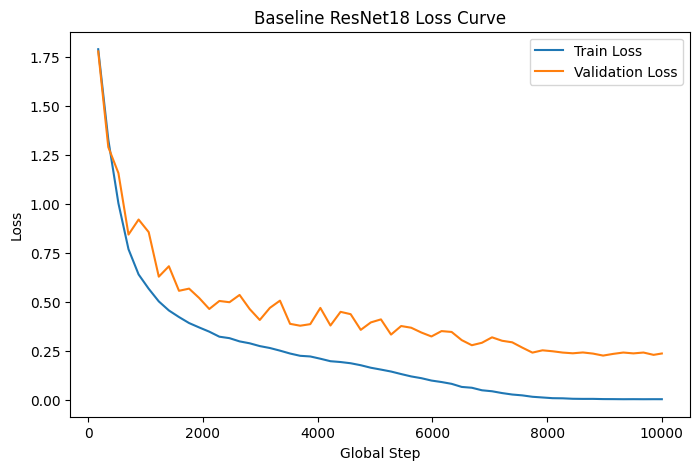

Saved: /content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/figures/baseline_resnet18_loss_curve.png


In [ ]:
# ============================================================
# CELL 21
#
# Visualisasi loss training
# ============================================================


plt.figure(
    figsize=(8,5)
)


plt.plot(

    history_df["global_step"],

    history_df["train_loss"],

    label="Train Loss"

)



plt.plot(

    history_df["global_step"],

    history_df["val_loss"],

    label="Validation Loss"

)



plt.xlabel(
    "Global Step"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Baseline ResNet18 Loss Curve"
)


plt.legend()



loss_curve_path = (

    FIGURE_DIR

    /

    "baseline_resnet18_loss_curve.png"

)



plt.savefig(

    loss_curve_path,

    dpi=300,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:",
    loss_curve_path
)

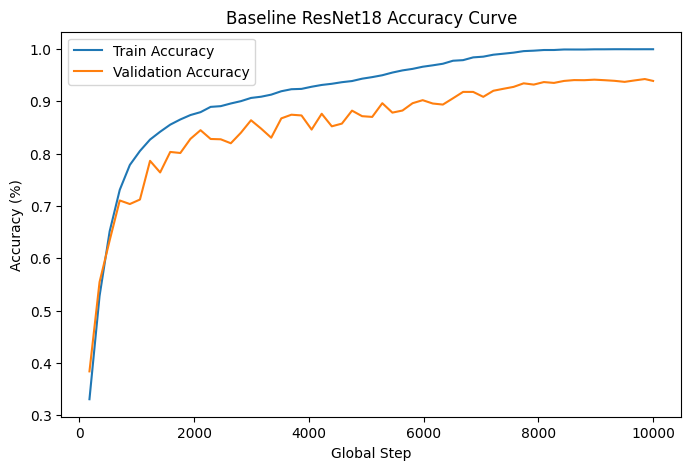

Saved: /content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/figures/baseline_resnet18_accuracy_curve.png


In [ ]:
# ============================================================
# CELL 22
#
# Visualisasi accuracy
# ============================================================


plt.figure(
    figsize=(8,5)
)



plt.plot(

    history_df["global_step"],

    history_df["train_accuracy"],

    label="Train Accuracy"

)



plt.plot(

    history_df["global_step"],

    history_df["val_accuracy"],

    label="Validation Accuracy"

)



plt.xlabel(
    "Global Step"
)



plt.ylabel(
    "Accuracy (%)"
)



plt.title(
    "Baseline ResNet18 Accuracy Curve"
)



plt.legend()



accuracy_curve_path = (

    FIGURE_DIR

    /

    "baseline_resnet18_accuracy_curve.png"

)



plt.savefig(

    accuracy_curve_path,

    dpi=300,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:",
    accuracy_curve_path
)

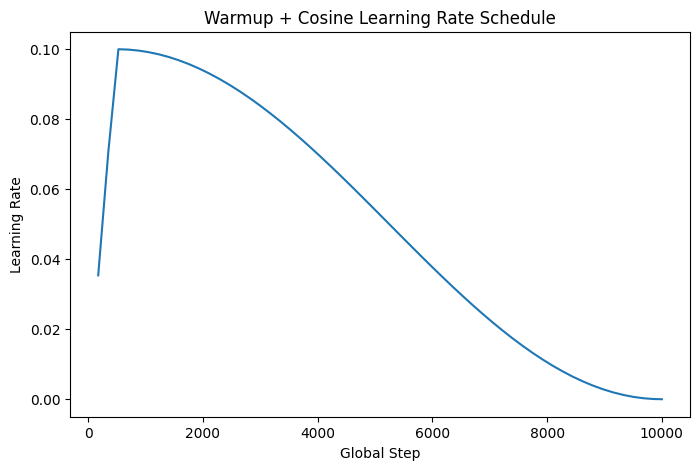

Saved: /content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/figures/baseline_resnet18_learning_rate_curve.png


In [ ]:
# ============================================================
# CELL 23
#
# Learning rate schedule visualization
# ============================================================


plt.figure(
    figsize=(8,5)
)



plt.plot(

    history_df["global_step"],

    history_df["learning_rate"]

)



plt.xlabel(
    "Global Step"
)


plt.ylabel(
    "Learning Rate"
)


plt.title(
    "Warmup + Cosine Learning Rate Schedule"
)



lr_curve_path = (

    FIGURE_DIR

    /

    "baseline_resnet18_learning_rate_curve.png"

)



plt.savefig(

    lr_curve_path,

    dpi=300,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:",
    lr_curve_path
)

In [ ]:
# ============================================================
# CELL 24
#
# Ringkasan visualisasi baseline
# ============================================================


print("="*70)

print("VISUALISASI BASELINE TERSEDIA")

print("="*70)


for file in [

    loss_curve_path,

    accuracy_curve_path,

    lr_curve_path

]:

    print(

        "✅",

        file.name

    )

VISUALISASI BASELINE TERSEDIA
✅ baseline_resnet18_loss_curve.png
✅ baseline_resnet18_accuracy_curve.png
✅ baseline_resnet18_learning_rate_curve.png


In [ ]:
# ============================================================
# CELL 25
#
# Validasi checkpoint baseline
#
# Memastikan checkpoint dapat digunakan kembali
# ============================================================


checkpoint_test = torch.load(

    checkpoint_path,

    map_location="cpu",

    weights_only=False

)



print("="*70)

print("CHECKPOINT INTEGRITY TEST")

print("="*70)



print(
    "Checkpoint berhasil dibaca"
)



print()

print(
    "Key checkpoint:"
)



for key in checkpoint_test.keys():

    print(
        "-",
        key
    )



print("="*70)

CHECKPOINT INTEGRITY TEST
Checkpoint berhasil dibaca

Key checkpoint:
- model_state_dict
- optimizer_state_dict
- scheduler_state_dict
- scaler_state_dict
- global_step
- config
- python_rng_state
- numpy_rng_state
- torch_rng_state
- cuda_rng_state
- generator_train_state


In [ ]:
# ============================================================
# CELL 26
#
# Reload model dari checkpoint
# ============================================================


model_eval = bangun_resnet_cifar(

    nama_model="resnet18",

    jumlah_kelas=10

)



model_eval.load_state_dict(

    checkpoint_test["model_state_dict"]

)



model_eval = model_eval.to(
    DEVICE
)



model_eval.eval()



print("="*70)

print("MODEL RELOAD BERHASIL")

print("="*70)


print(
    "Device:",
    DEVICE
)

MODEL RELOAD BERHASIL
Device: cuda


In [ ]:
# ============================================================
# CELL 27
#
# Final test evaluation dataset
#
# Test hanya digunakan setelah training selesai
# ============================================================


from torchvision.datasets import CIFAR10



test_dataset = CIFAR10(

    root="/content/data",

    train=False,

    download=True,

    transform=eval_transform

)



test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)



print("="*70)

print("TEST DATASET SIAP")

print("="*70)


print(
    "Jumlah test sample:",
    len(test_dataset)
)

TEST DATASET SIAP
Jumlah test sample: 10000


In [ ]:
# ============================================================
# CELL 28
#
# Evaluasi final test
# ============================================================


all_predictions = []

all_labels = []



test_loss_total = 0.0

criterion_eval = nn.CrossEntropyLoss()



with torch.no_grad():

    for gambar, label in test_loader:


        gambar = gambar.to(
            DEVICE
        )


        label = label.to(
            DEVICE
        )



        output = model_eval(
            gambar
        )



        loss = criterion_eval(

            output,

            label

        )



        test_loss_total += loss.item()



        prediksi = torch.argmax(

            output,

            dim=1

        )



        all_predictions.extend(

            prediksi.cpu()
            .numpy()

        )


        all_labels.extend(

            label.cpu()
            .numpy()

        )



test_loss = (

    test_loss_total

    /

    len(test_loader)

)



test_accuracy = accuracy_score(

    all_labels,

    all_predictions

)



test_f1 = f1_score(

    all_labels,

    all_predictions,

    average="macro"

)



print("="*70)

print("FINAL TEST EVALUATION")

print("="*70)



print(
    "Test Loss:",
    round(test_loss,4)
)


print(
    "Test Accuracy:",
    round(test_accuracy*100,2),
    "%"
)


print(
    "Macro F1:",
    round(test_f1,4)
)

FINAL TEST EVALUATION
Test Loss: 0.2469
Test Accuracy: 94.09 %
Macro F1: 0.9409


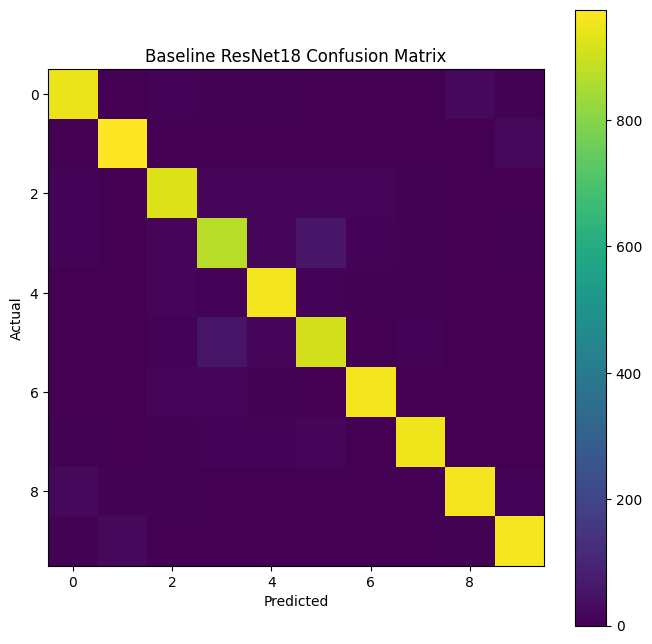

Saved: /content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/figures/baseline_resnet18_confusion_matrix.png


In [ ]:
# ============================================================
# CELL 29
#
# Confusion Matrix
# ============================================================


cm = confusion_matrix(

    all_labels,

    all_predictions

)



plt.figure(

    figsize=(8,8)

)



plt.imshow(cm)



plt.title(
    "Baseline ResNet18 Confusion Matrix"
)



plt.xlabel(
    "Predicted"
)



plt.ylabel(
    "Actual"
)



plt.colorbar()



cm_path = (

    FIGURE_DIR

    /

    "baseline_resnet18_confusion_matrix.png"

)



plt.savefig(

    cm_path,

    dpi=300,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:",
    cm_path
)

In [ ]:
# ============================================================
# CELL 30
#
# Menyimpan metadata eksperimen
# ============================================================


metadata = {

    "experiment":
        "baseline_resnet18",


    "dataset":
        "CIFAR-10 clean",


    "model":
        "ResNet18",


    "global_step":
        global_step_akhir,


    "test_loss":
        float(test_loss),


    "test_accuracy":
        float(test_accuracy),


    "test_macro_f1":
        float(test_f1),


    "protocol":
        protocol

}



metadata_path = (

    META_DIR

    /

    "baseline_resnet18_metadata.json"

)



with open(

    metadata_path,

    "w"

) as file:

    json.dump(

        metadata,

        file,

        indent=4

    )



print("="*70)

print("METADATA BASELINE TERSIMPAN")

print("="*70)


print(
    metadata_path
)

METADATA BASELINE TERSIMPAN
/content/drive/MyDrive/skripsi_label_noise/outputs/phase_8_baseline/run_metadata/baseline_resnet18_metadata.json


In [ ]:
# ============================================================
# CELL 31
#
# Audit akhir Fase 8
# ============================================================


print("="*70)

print(
    "FASE 8 — BASELINE EXPERIMENT FINAL AUDIT"
)

print("="*70)



audit = {


"checkpoint":
    checkpoint_path.exists(),


"history csv":
    history_path.exists(),


"loss curve":
    loss_curve_path.exists(),


"accuracy curve":
    accuracy_curve_path.exists(),


"lr curve":
    lr_curve_path.exists(),


"confusion matrix":
    cm_path.exists(),


"metadata":
    metadata_path.exists(),


"test metric finite":
    np.isfinite(test_loss)

}



for item,status in audit.items():

    print(

        "✅" if status else "❌",

        item

    )



print("="*70)

print(
    "BASELINE EXPERIMENT SELESAI"
)

print("="*70)

FASE 8 — BASELINE EXPERIMENT FINAL AUDIT
✅ checkpoint
✅ history csv
✅ loss curve
✅ accuracy curve
✅ lr curve
✅ confusion matrix
✅ metadata
✅ test metric finite
BASELINE EXPERIMENT SELESAI


In [ ]:
# ============================================================
# AUDIT GIT STATUS SEBELUM COMMIT
# ============================================================

import subprocess


REPO_PATH = "/content/label-noise-thesis"


def jalankan_git(command):

    hasil = subprocess.run(

        command,

        cwd=REPO_PATH,

        capture_output=True,

        text=True

    )

    print("$", " ".join(command))

    print(hasil.stdout)

    if hasil.stderr:

        print(hasil.stderr)

    return hasil



print("="*70)
print("AUDIT GIT STATUS")
print("="*70)



status = jalankan_git(

    [
        "git",
        "status",
        "--short"
    ]

)



print("="*70)

print("REMOTE")

print("="*70)



jalankan_git(

    [
        "git",
        "remote",
        "-v"
    ]

)


AUDIT GIT STATUS
$ git status --short

REMOTE
$ git remote -v
origin	https://github.com/luthfiaw13/label-noise-thesis.git (fetch)
origin	https://github.com/luthfiaw13/label-noise-thesis.git (push)



CompletedProcess(args=['git', 'remote', '-v'], returncode=0, stdout='origin\thttps://github.com/luthfiaw13/label-noise-thesis.git (fetch)\norigin\thttps://github.com/luthfiaw13/label-noise-thesis.git (push)\n', stderr='')

In [15]:
import sys

sys.path.append(
    "/content/label-noise-thesis"
)


import numpy as np


from src.noise.symmetric import (
    generate_symmetric_noise
)


from src.noise.pairflip import (
    generate_pairflip_noise
)



labels = np.tile(
    np.arange(10),
    5000
)


print(
    "Jumlah label:",
    len(labels)
)

Jumlah label: 50000


In [16]:
noisy_sym, mask_sym = generate_symmetric_noise(
    labels,
    noise_rate=0.4,
    num_classes=10,
    seed=42
)


print(
    "Symmetric noise"
)

print(
    "Berubah:",
    mask_sym.sum()
)

print(
    "Persentase:",
    mask_sym.mean()
)

Symmetric noise
Berubah: 20000
Persentase: 0.4


In [17]:
noisy_pair, mask_pair = generate_pairflip_noise(
    labels,
    noise_rate=0.4,
    seed=42
)


print(
    "Pair flip noise"
)

print(
    "Berubah:",
    mask_pair.sum()
)

print(
    "Persentase:",
    mask_pair.mean()
)

Pair flip noise
Berubah: 20000
Persentase: 0.4


In [18]:
a,_ = generate_symmetric_noise(
    labels,
    0.4,
    10,
    seed=42
)


b,_ = generate_symmetric_noise(
    labels,
    0.4,
    10,
    seed=42
)


print(
    np.array_equal(a,b)
)

True


In [19]:
from collections import Counter


perubahan_sym = []


for asli, baru in zip(
    labels,
    noisy_sym
):

    if asli != baru:

        perubahan_sym.append(
            (
                asli,
                baru
            )
        )


print(
    "Jumlah perubahan:",
    len(perubahan_sym)
)


print(
    Counter(perubahan_sym).most_common(10)
)

Jumlah perubahan: 20000
[((np.int64(7), np.int64(1)), 267), ((np.int64(9), np.int64(7)), 267), ((np.int64(4), np.int64(7)), 259), ((np.int64(6), np.int64(5)), 246), ((np.int64(7), np.int64(2)), 246), ((np.int64(8), np.int64(9)), 244), ((np.int64(5), np.int64(2)), 244), ((np.int64(1), np.int64(9)), 244), ((np.int64(3), np.int64(7)), 243), ((np.int64(0), np.int64(3)), 243)]


In [20]:
perubahan_pair = []


for asli, baru in zip(
    labels,
    noisy_pair
):

    if asli != baru:

        perubahan_pair.append(
            (
                asli,
                baru
            )
        )


print(
    "Jumlah perubahan:",
    len(perubahan_pair)
)


print(
    Counter(perubahan_pair).most_common(10)
)

Jumlah perubahan: 20000
[((np.int64(4), np.int64(2)), 2044), ((np.int64(1), np.int64(0)), 2043), ((np.int64(6), np.int64(7)), 2016), ((np.int64(9), np.int64(8)), 2016), ((np.int64(7), np.int64(6)), 2014), ((np.int64(3), np.int64(5)), 1992), ((np.int64(5), np.int64(3)), 1983), ((np.int64(8), np.int64(9)), 1981), ((np.int64(2), np.int64(4)), 1966), ((np.int64(0), np.int64(1)), 1945)]
